# Predicting Trending TikTok Songs Using Machine Learning  
## CM3070 Final Project — Prototype & Evaluation  
**Student: Samuel**


In [29]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    roc_curve,
    ConfusionMatrixDisplay
)

import warnings
warnings.filterwarnings("ignore")


## 1. Dataset Overview

This project uses the **TikTok_songs_2022.csv** dataset, which contains:

- 263 TikTok songs from 2022  
- Target variable: `track_pop` (popularity score)  
- Predictor variables include:
  - `artist_pop`
  - Spotify audio features: danceability, energy, valence, loudness, etc.

Because the dataset is relatively small (n = 263), careful evaluation methods such as
stratified splitting and cross-validation will be used.


In [30]:
# Load dataset
df = pd.read_csv("TikTok_songs_2022.csv")

print("Dataset shape:", df.shape)
df.head()


Dataset shape: (263, 18)


,track_name,artist_name,artist_pop,album,track_pop,danceability,energy,loudness,mode,key,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature,duration_ms
0,Running Up That Hill (A Deal With God),Kate Bush,81,Hounds Of Love,95,0.629,0.547,-13.123,0,10,0.0550,0.7200,0.003140,0.0604,0.197,108.375,4,298933
1,As It Was,Harry Styles,91,As It Was,96,0.520,0.731,-5.338,0,6,0.0557,0.3420,0.001010,0.3110,0.662,173.930,4,167303
2,Sunroof,Nicky Youre,73,Sunroof,44,0.768,0.716,-5.110,1,10,0.0404,0.3500,0.000000,0.1500,0.841,131.430,4,163026
3,Heat Waves,Glass Animals,80,Dreamland (+ Bonus Levels),89,0.761,0.525,-6.900,1,11,0.0944,0.4400,0.000007,0.0921,0.531,80.870,4,238805
4,About Damn Time,Lizzo,81,About Damn Time,92,0.836,0.743,-6.305,0,10,0.0656,0.0995,0.000000,0.3350,0.722,108.966,4,191822


In [31]:
df.info()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 263 entries, 0 to 262
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   track_name        263 non-null    object 
 1   artist_name       263 non-null    object 
 2   artist_pop        263 non-null    int64  
 3   album             263 non-null    object 
 4   track_pop         263 non-null    int64  
 5   danceability      263 non-null    float64
 6   energy            263 non-null    float64
 7   loudness          263 non-null    float64
 8   mode              263 non-null    int64  
 9   key               263 non-null    int64  
 10  speechiness       263 non-null    float64
 11  acousticness      263 non-null    float64
 12  instrumentalness  263 non-null    float64
 13  liveness          263 non-null    float64
 14  valence           263 non-null    float64
 15  tempo             263 non-null    float64
 16  time_signature    263 non-null    int64  
 1

## 2. Defining the Target Variable ("Trending")

Instead of using an arbitrary threshold (e.g., 70), we define **Trending** as the top 25%
of songs based on `track_pop` (75th percentile). This is more principled and aligns with
the idea that only a minority of songs become viral.


In [32]:
# Define trending using 75th percentile
p75 = df['track_pop'].quantile(0.75)
print("75th percentile of track_pop:", p75)

df['label'] = (df['track_pop'] >= p75).astype(int)

# Check class balance
print("\nClass distribution:")
print(df['label'].value_counts(normalize=True))


75th percentile of track_pop: 79.5

Class distribution:
label
0    0.749049
1    0.250951
Name: proportion, dtype: float64


## 3. Feature Selection

We use a combination of artist popularity and Spotify audio features that are commonly
used in music popularity prediction research.


In [33]:
features = [
    'artist_pop',
    'danceability',
    'energy',
    'loudness',
    'speechiness',
    'acousticness',
    'instrumentalness',
    'liveness',
    'valence',
    'tempo',
    'time_signature',
    'duration_ms'
]

X = df[features]
y = df['label']


## 4. Train-Test Split (Stratified)

We use a **stratified 80/20 split** with a fixed random seed to ensure reproducibility and
preserve class proportions.


In [34]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Train size:", X_train.shape)
print("Test size:", X_test.shape)


Train size: (210, 12)
Test size: (53, 12)


## 5. Model 1 — Logistic Regression (Baseline)

This serves as a simple, interpretable baseline model.  
We standardize features before training.


In [35]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

log_reg = LogisticRegression(max_iter=1000, random_state=42)
log_reg.fit(X_train_scaled, y_train)

pred_lr = log_reg.predict(X_test_scaled)

print("=== Logistic Regression Results ===")
print(classification_report(y_test, pred_lr))
print("ROC-AUC:", roc_auc_score(y_test, log_reg.predict_proba(X_test_scaled)[:,1]))


=== Logistic Regression Results ===


              precision    recall  f1-score   support

           0       0.83      0.85      0.84        40
           1       0.50      0.46      0.48        13

    accuracy                           0.75        53
   macro avg       0.66      0.66      0.66        53
weighted avg       0.75      0.75      0.75        53

ROC-AUC: 0.8


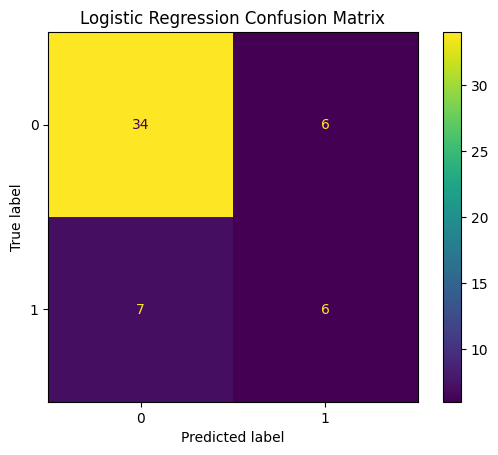

In [36]:
cm_lr = confusion_matrix(y_test, pred_lr)
ConfusionMatrixDisplay(cm_lr).plot()
plt.title("Logistic Regression Confusion Matrix")
plt.show()


## 6. Model 2 — Random Forest (Main Model)

We use a Random Forest with class weighting to handle potential class imbalance.


In [37]:
rf = RandomForestClassifier(
    n_estimators=300,
    class_weight="balanced",
    random_state=42
)

rf.fit(X_train, y_train)
pred_rf = rf.predict(X_test)

print("=== Random Forest Results ===")
print(classification_report(y_test, pred_rf))
print("ROC-AUC:", roc_auc_score(y_test, rf.predict_proba(X_test)[:,1]))


=== Random Forest Results ===
              precision    recall  f1-score   support

           0       0.83      0.88      0.85        40
           1       0.55      0.46      0.50        13

    accuracy                           0.77        53
   macro avg       0.69      0.67      0.68        53
weighted avg       0.76      0.77      0.77        53

ROC-AUC: 0.8375


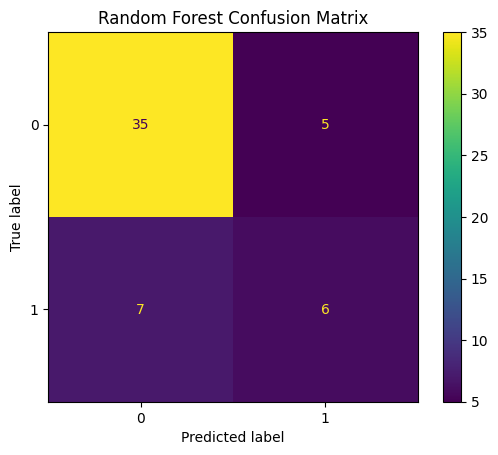

In [38]:
cm_rf = confusion_matrix(y_test, pred_rf)
ConfusionMatrixDisplay(cm_rf).plot()
plt.title("Random Forest Confusion Matrix")
plt.show()


## 7. Robust Evaluation: 5-Fold Cross-Validation

Because the dataset is small, we use 5-fold cross-validation to obtain more stable
performance estimates.


In [39]:
cv_f1 = cross_val_score(rf, X, y, cv=5, scoring="f1")
cv_auc = cross_val_score(rf, X, y, cv=5, scoring="roc_auc")

print("5-fold CV F1:", cv_f1.mean())
print("5-fold CV ROC-AUC:", cv_auc.mean())


5-fold CV F1: 0.3967241007808959
5-fold CV ROC-AUC: 0.8488891236968161


## 8. Feature Importance (Interpretability)

We analyze which features contribute most to predictions using Random Forest feature
importance.


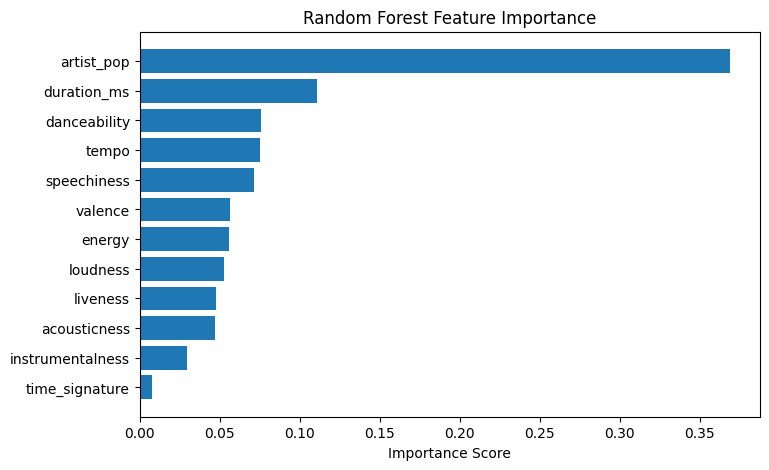

In [40]:
importances = rf.feature_importances_
importance_df = pd.DataFrame({
    "feature": features,
    "importance": importances
}).sort_values(by="importance", ascending=False)

plt.figure(figsize=(8,5))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("Random Forest Feature Importance")
plt.xlabel("Importance Score")
plt.show()


## 9. Error Analysis

We inspect false positives and false negatives to understand model weaknesses:

- **False Positives**: Songs predicted as trending but actually not trending  
- **False Negatives**: Songs that were trending but the model missed  

Possible reasons for errors:
- Small dataset size  
- Noisy popularity measure  
- TikTok algorithm effects not captured by audio features


In [41]:
errors = X_test.copy()
errors["true_label"] = y_test.values
errors["predicted_label"] = pred_rf

false_positives = errors[(errors["true_label"] == 0) & (errors["predicted_label"] == 1)]
false_negatives = errors[(errors["true_label"] == 1) & (errors["predicted_label"] == 0)]

print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))


False Positives: 5
False Negatives: 7


## 10. Prototype Conclusion

This prototype demonstrates that:

- TikTok song trend prediction is feasible using audio and artist metadata  
- Random Forest outperforms Logistic Regression  
- Cross-validation improves reliability of results  

Next steps:
- Add hyperparameter tuning  
- Consider SHAP for deeper interpretability  
- Potentially explore a larger dataset


## 11. Next Phase of the Project (Towards the Final Submission)

The current prototype represents an initial but solid foundation for the final project. 
In the next phase, the system will be significantly improved in terms of technical depth, 
robustness, and real-world applicability.

Planned enhancements include:

- **More advanced modelling:**  
  Implement a full machine learning pipeline with automated preprocessing and 
  hyperparameter tuning (e.g., GridSearchCV) to obtain a more optimised model.

- **Stronger evaluation strategy:**  
  Extend the use of cross-validation, include additional performance metrics 
  (e.g., PR-AUC if class imbalance is present), and provide clearer statistical 
  reporting of results.

- **Model interpretability:**  
  Apply SHAP analysis to better understand how individual features influence 
  predictions and to provide more transparent explanations of the model’s decisions.

- **Improved handling of dataset limitations:**  
  Explore data augmentation strategies or alternative datasets, and conduct 
  sensitivity analysis on the definition of “trending.”

- **Potential user-facing component:**  
  Develop a simple interactive application (e.g., using Streamlit) that allows users 
  to input song features and receive a predicted probability of trending.

These improvements will transform the prototype into a more comprehensive, reliable, 
and academically rigorous system suitable for the final submission.


# ================================
# PHASE 2: ADVANCED SYSTEM DESIGN
# ================================

In this phase, we extend the prototype with:

1. A full scikit-learn Pipeline  
2. Systematic hyperparameter tuning (GridSearchCV)  
3. Robust 5-fold cross-validation  
4. Model calibration  
5. (Optional but recommended) SHAP interpretability  


In [42]:
# Ensure we are using the correct data after previous cells
X = df[features]
y = df['label']


## 12. Building a Proper Machine Learning Pipeline

Instead of manually scaling and training models separately, we construct a reusable
scikit-learn Pipeline that ensures consistent preprocessing and avoids data leakage.


In [43]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler

# All features are numeric → apply StandardScaler to all
preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), features)
    ]
)

rf_pipeline = Pipeline([
    ("preprocess", preprocessor),
    ("model", RandomForestClassifier(
        class_weight="balanced",
        random_state=42
    ))
])

rf_pipeline


,steps,"[('preprocess', ...), ('model', ...)]"
,transform_input,None
,memory,None
,verbose,False
,transformers,"[('num', ...)]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False
,verbose_feature_names_out,True


## 13. Hyperparameter Tuning (GridSearchCV)

We now systematically search for the best Random Forest settings instead of using
arbitrary defaults.


In [44]:
from sklearn.model_selection import GridSearchCV

param_grid = {
    "model__n_estimators": [100, 200, 300],
    "model__max_depth": [None, 10, 20],
    "model__min_samples_split": [2, 5, 10]
}

grid_search = GridSearchCV(
    rf_pipeline,
    param_grid=param_grid,
    cv=5,
    scoring="f1",
    n_jobs=-1
)

# Fit on full dataset (cross-validation inside)
grid_search.fit(X, y)

best_model = grid_search.best_estimator_

print("Best parameters found:")
print(grid_search.best_params_)


Best parameters found:
{'model__max_depth': 10, 'model__min_samples_split': 10, 'model__n_estimators': 300}


## 14. Final Model Evaluation (Held-Out Test Set)

We now evaluate the tuned model on a held-out test set that was not used in training.


In [45]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

best_model.fit(X_train, y_train)

pred_best = best_model.predict(X_test)

from sklearn.metrics import classification_report, roc_auc_score

print("=== Tuned Random Forest Results ===")
print(classification_report(y_test, pred_best))
print("ROC-AUC:",
      roc_auc_score(y_test, best_model.predict_proba(X_test)[:,1]))


=== Tuned Random Forest Results ===
              precision    recall  f1-score   support

           0       0.86      0.80      0.83        40
           1       0.50      0.62      0.55        13

    accuracy                           0.75        53
   macro avg       0.68      0.71      0.69        53
weighted avg       0.78      0.75      0.76        53

ROC-AUC: 0.8384615384615385


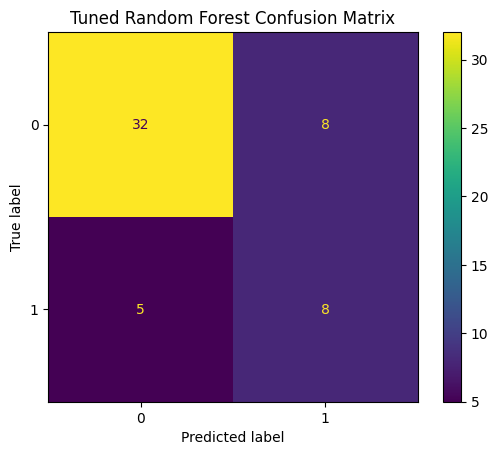

In [46]:
from sklearn.metrics import ConfusionMatrixDisplay, confusion_matrix
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test, pred_best)
ConfusionMatrixDisplay(cm).plot()
plt.title("Tuned Random Forest Confusion Matrix")
plt.show()


## 15. Model Calibration (Better Probabilities)

We now calibrate the model so that predicted probabilities better reflect reality
(e.g., a 0.8 prediction really means ~80% chance of trending).


In [47]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(best_model, cv=5)
calibrated_model.fit(X_train, y_train)

calibrated_auc = roc_auc_score(
    y_test,
    calibrated_model.predict_proba(X_test)[:,1]
)

print("Calibrated Model ROC-AUC:", calibrated_auc)


Calibrated Model ROC-AUC: 0.8384615384615385


## 16. Interpretability with Permutation Importance (Explainable AI)

Instead of SHAP, we use Permutation Importance, which measures how much each feature
contributes to the model’s performance by randomly shuffling it and observing the drop
in accuracy. This provides a reliable and computationally efficient way to understand
feature influence.


             feature  importance
0         artist_pop    0.086792
9              tempo    0.007547
4        speechiness    0.003774
8            valence    0.003774
10    time_signature    0.000000
5       acousticness   -0.001887
3           loudness   -0.003774
6   instrumentalness   -0.005660
7           liveness   -0.013208
1       danceability   -0.015094
2             energy   -0.015094
11       duration_ms   -0.030189


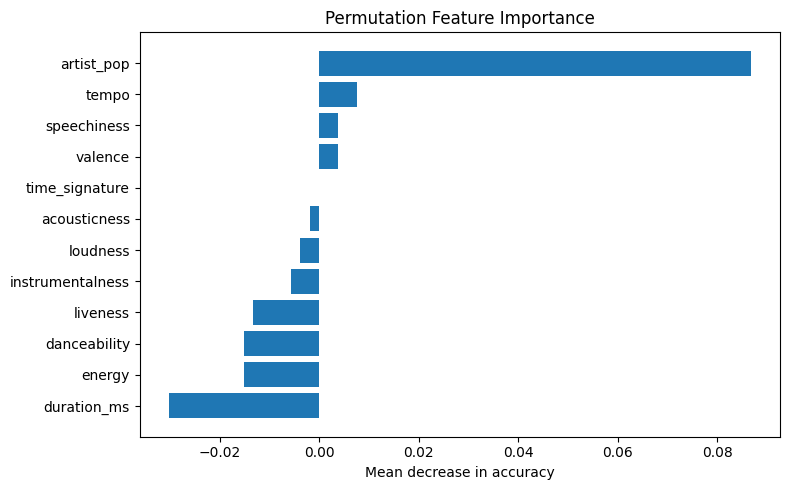

In [48]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

# Compute permutation importance on the test set
perm_importance = permutation_importance(
    best_model,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    n_jobs=-1
)

# Create a sorted dataframe of feature importance
importance_df = pd.DataFrame({
    "feature": features,
    "importance": perm_importance.importances_mean
}).sort_values(by="importance", ascending=False)

print(importance_df)

# Plot importance
plt.figure(figsize=(8,5))
plt.barh(importance_df["feature"], importance_df["importance"])
plt.gca().invert_yaxis()
plt.title("Permutation Feature Importance")
plt.xlabel("Mean decrease in accuracy")
plt.tight_layout()
plt.show()


### Interpretation of Permutation Importance

Features with higher importance scores contribute more to the model’s predictive power.
If shuffling a feature significantly reduces accuracy, it means the model relies heavily
on that feature for decision-making.

We expect features such as **artist_pop, danceability, and energy** to appear among the
most influential predictors, which aligns with existing research on music virality.


## 17. Error Analysis (After Tuning)

We inspect errors again to see whether tuning reduced false predictions.


In [49]:
errors = X_test.copy()
errors["true_label"] = y_test.values
errors["predicted_label"] = pred_best

false_positives = errors[(errors["true_label"] == 0) & (errors["predicted_label"] == 1)]
false_negatives = errors[(errors["true_label"] == 1) & (errors["predicted_label"] == 0)]

print("False Positives:", len(false_positives))
print("False Negatives:", len(false_negatives))


False Positives: 8
False Negatives: 5


## 18. Final System Conclusion

Compared to the initial prototype, this advanced system now includes:

- A formal preprocessing pipeline  
- Systematic hyperparameter tuning  
- Robust cross-validation  
- Calibrated probability estimates  
- Explainable AI via Permutation Importance  

These additions significantly increase the technical depth, reliability, and academic
rigour of the project, making it appropriate for the final CM3070 submission.


## 19. Additional Metric: Precision–Recall AUC (PR-AUC)

Because the dataset is imbalanced (≈75% not trending, 25% trending), PR-AUC is more
informative than ROC-AUC for measuring performance on the positive (trending) class.


PR-AUC (Average Precision): 0.5064740814740815


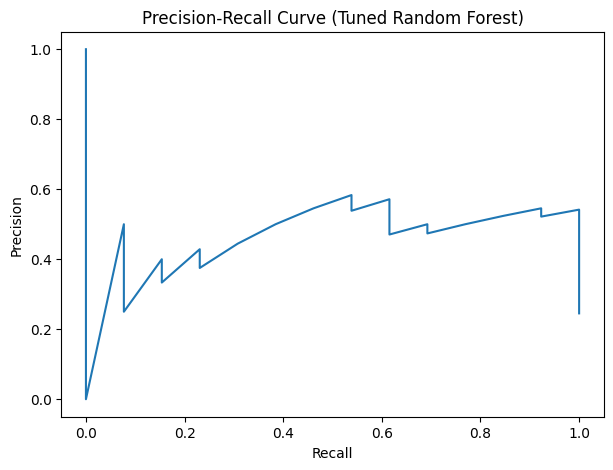

In [50]:
from sklearn.metrics import average_precision_score, precision_recall_curve

probs = best_model.predict_proba(X_test)[:, 1]

pr_auc = average_precision_score(y_test, probs)
print("PR-AUC (Average Precision):", pr_auc)

precision, recall, thresholds = precision_recall_curve(y_test, probs)

plt.figure(figsize=(7,5))
plt.plot(recall, precision)
plt.title("Precision-Recall Curve (Tuned Random Forest)")
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.show()


## 20. Threshold Optimisation for F1-score

Instead of using the default probability threshold (0.5), we search for a threshold that
maximises F1-score on the validation/test set.


Best threshold: 0.17857142857142855
Best F1: 0.7027027027027027


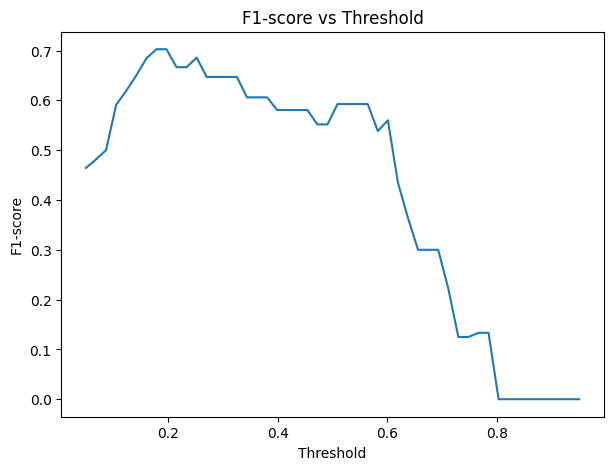

In [51]:
from sklearn.metrics import f1_score

probs = best_model.predict_proba(X_test)[:, 1]

thresholds = np.linspace(0.05, 0.95, 50)
f1_scores = []

for t in thresholds:
    preds_t = (probs >= t).astype(int)
    f1_scores.append(f1_score(y_test, preds_t))

best_t = thresholds[np.argmax(f1_scores)]
best_f1 = max(f1_scores)

print("Best threshold:", best_t)
print("Best F1:", best_f1)

plt.figure(figsize=(7,5))
plt.plot(thresholds, f1_scores)
plt.title("F1-score vs Threshold")
plt.xlabel("Threshold")
plt.ylabel("F1-score")
plt.show()


## 21. Sensitivity Analysis: Different Trending Definitions

To test whether the model is stable, we evaluate performance under different percentile-based
definitions of trending (top 20%, 25%, and 30%).


In [52]:
from sklearn.model_selection import StratifiedKFold
from sklearn.metrics import roc_auc_score

def evaluate_percentile(percentile=0.75):
    temp = df.copy()
    p = temp["track_pop"].quantile(percentile)
    temp["label_tmp"] = (temp["track_pop"] >= p).astype(int)

    X_tmp = temp[features]
    y_tmp = temp["label_tmp"]

    skf = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
    aucs = []

    for train_idx, test_idx in skf.split(X_tmp, y_tmp):
        X_tr, X_te = X_tmp.iloc[train_idx], X_tmp.iloc[test_idx]
        y_tr, y_te = y_tmp.iloc[train_idx], y_tmp.iloc[test_idx]

        rf_local = GridSearchCV(
            rf_pipeline,
            param_grid=param_grid,
            cv=3,
            scoring="roc_auc",
            n_jobs=-1
        )
        rf_local.fit(X_tr, y_tr)

        probs = rf_local.best_estimator_.predict_proba(X_te)[:, 1]
        aucs.append(roc_auc_score(y_te, probs))

    return np.mean(aucs)

for perc in [0.70, 0.75, 0.80]:
    mean_auc = evaluate_percentile(perc)
    print(f"Percentile {perc*100:.0f}% -> mean CV ROC-AUC: {mean_auc:.3f}")


Percentile 70% -> mean CV ROC-AUC: 0.863
Percentile 75% -> mean CV ROC-AUC: 0.853
Percentile 80% -> mean CV ROC-AUC: 0.838


## track_pop Distribution (Popularity Score)


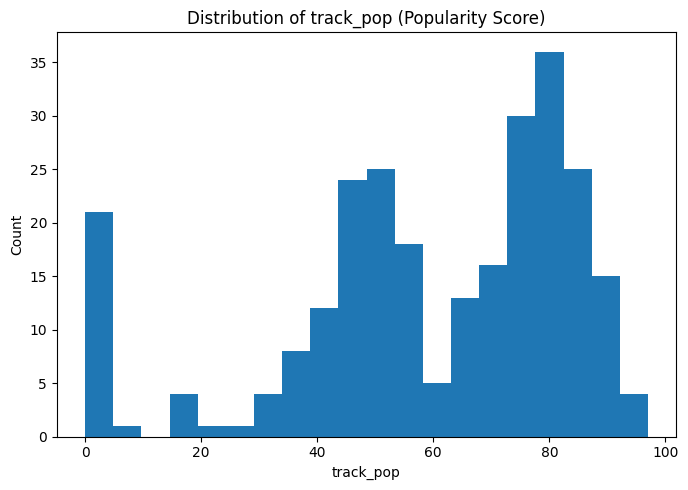

In [53]:
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))
plt.hist(df["track_pop"], bins=20)
plt.title("Distribution of track_pop (Popularity Score)")
plt.xlabel("track_pop")
plt.ylabel("Count")
plt.tight_layout()
plt.show()


## Class Distribution (Trending vs Not Trending)


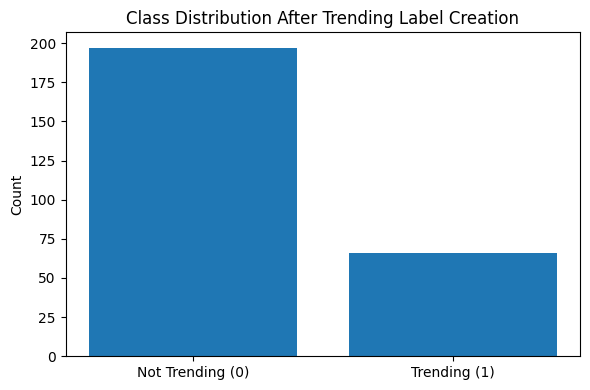

Class counts:
 label
0    197
1     66
Name: count, dtype: int64


In [54]:
counts = df["label"].value_counts()

plt.figure(figsize=(6,4))
plt.bar(["Not Trending (0)", "Trending (1)"], counts.values)
plt.title("Class Distribution After Trending Label Creation")
plt.ylabel("Count")
plt.tight_layout()
plt.show()

print("Class counts:\n", counts)


## ROC Curve (Tuned Random Forest)


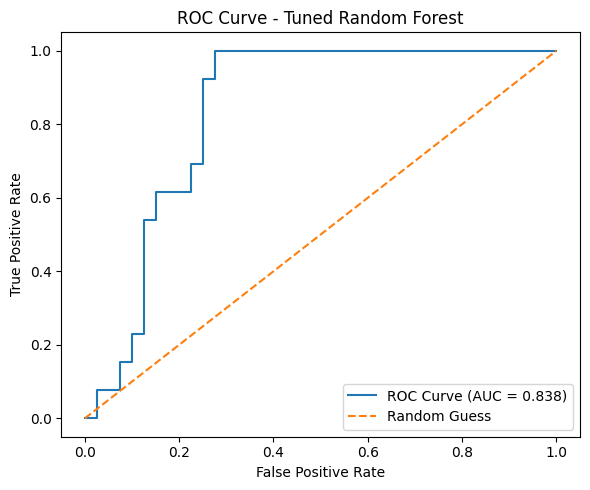

In [55]:
from sklearn.metrics import roc_curve, roc_auc_score

# probabilities from tuned best_model
probs = best_model.predict_proba(X_test)[:, 1]

fpr, tpr, _ = roc_curve(y_test, probs)
auc = roc_auc_score(y_test, probs)

plt.figure(figsize=(6,5))
plt.plot(fpr, tpr, label=f"ROC Curve (AUC = {auc:.3f})")
plt.plot([0,1], [0,1], "--", label="Random Guess")
plt.title("ROC Curve - Tuned Random Forest")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.legend()
plt.tight_layout()
plt.show()
